In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch

In [2]:
dataset = pd.read_csv(r"./Salary Data.csv")
dataset.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [3]:
X = dataset["Experience Years"].values
y = dataset["Salary"].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,random_state=12)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((28,), (12,), (28,), (12,))

In [5]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((28, 1), (12, 1), (28, 1), (12, 1))

In [6]:
X_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

y_scaler =StandardScaler()

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

In [ ]:
# y_train = y_scaler.inverse_transform(y_train)
# y_test = y_scaler.inverse_transform(y_test)

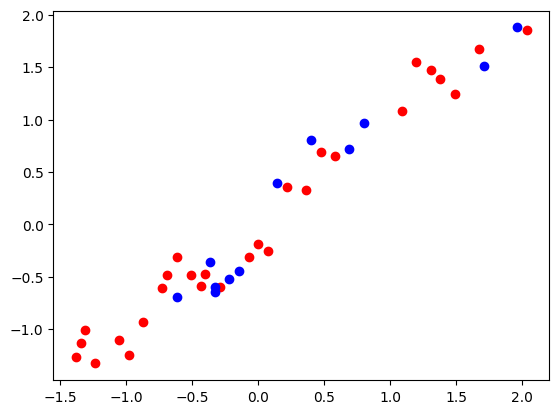

In [7]:
plt.scatter(X_train,y_train, c="r")
plt.scatter(X_test,y_test,c="b")

In [8]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


(torch.Size([28, 1]),
 torch.Size([12, 1]),
 torch.Size([28, 1]),
 torch.Size([12, 1]))

In [9]:
def linear_regression(x,w0,w1):
    return x* w1 + w0

In [10]:
w0 = torch.randn(1)
w1 = torch.randn(1)
print(w0,w1)

y_hat = linear_regression(X_train,w0,w1)

tensor([0.0870]) tensor([-0.1234])


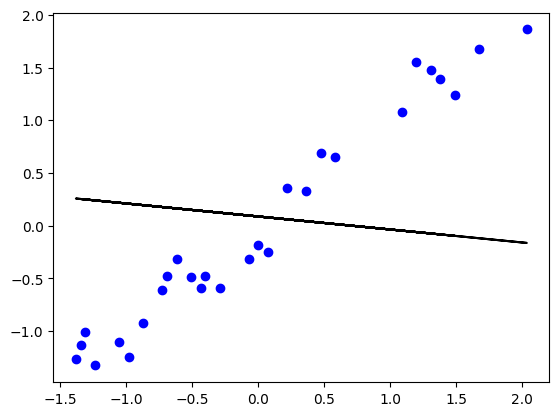

In [11]:
plt.scatter(X_train,y_train, c="blue")
plt.plot(X_train,y_hat, c="black")

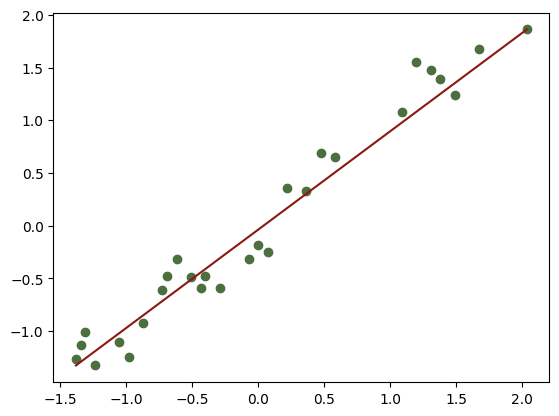

In [12]:
Xr = np.linspace(min(X_train),max(X_train),200)
yr = np.linspace(min(y_train),max(y_train),200)

plt.scatter(X_train,y_train, color=(75/255 , 111/255 , 62/255))
plt.plot(Xr,yr, color= (138/255,25/255,15/255))

In [13]:
Xr = torch.linspace(X_train.min(),X_train.max(),50).unsqueeze(1)
yr = torch.linspace(y_train.min(),y_train.max(),50).unsqueeze(1)
y_hat = linear_regression(Xr, w0, w1)
Xr.shape, yr.shape, y_hat.shape

(torch.Size([50, 1]), torch.Size([50, 1]), torch.Size([50, 1]))

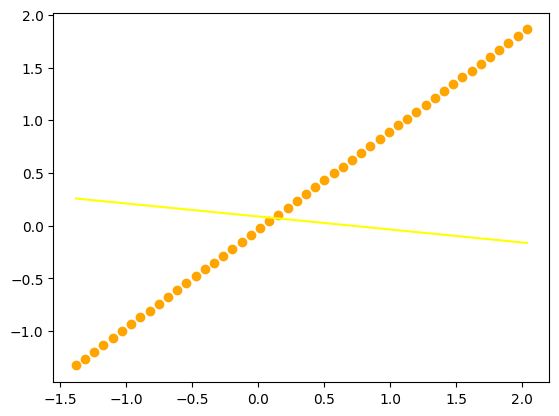

In [14]:
plt.scatter(Xr, yr, c="orange")
plt.plot(Xr,y_hat, c="yellow")

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

LinearRegression()

In [17]:
y_hat = model1.predict(X_test)

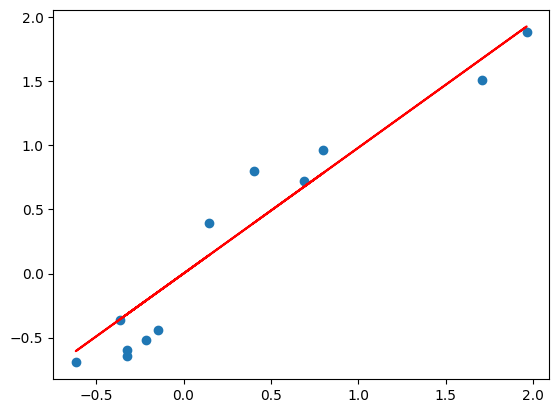

In [18]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_hat,c="red")

In [19]:
class Linear_regression:

    def __init__(self):
        self.w0 = torch.randn(1)
        self.w1 = torch.randn(1)

    def __call__(self, x):
        return x * self.w1 + self.w0

    def __repr__(self):
        return "This is our Linear Regression"

In [20]:
model2 = Linear_regression()
model2 , model2.w0, model2.w1

(This is our Linear Regression, tensor([0.0142]), tensor([-1.1601]))

In [21]:
model2(X_train).shape

torch.Size([28, 1])

In [22]:
def mse(y,y_hat):
    return torch.mean(((y-y_hat) **2))

In [23]:
def mae(y,y_hat):
    return torch.mean(torch.abs((y-y_hat)))

In [24]:
theta0 = 0
theta1 = torch.linspace(-10,10,100)

losses = torch.zeros(len(theta1))

for i, t1 in enumerate(theta1):
    y_hat = linear_regression(X_train, theta0, t1)
    losses[i] = mse(y_train,y_hat)

losses.shape

torch.Size([100])

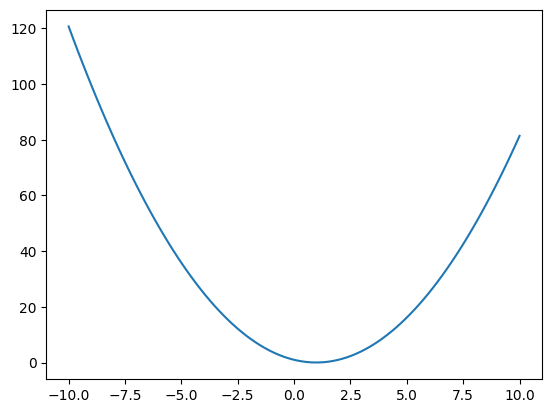

In [25]:
plt.plot(theta1,losses)

In [26]:
min_loss = losses.min()
for i,j in zip(theta1,losses):
    if j == min_loss:
        best_theta1 = i
        break
best_theta1  

tensor(0.9091)

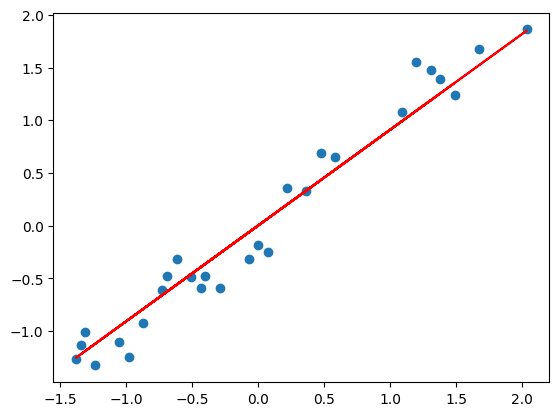

In [27]:
y_hat5 = X_train * best_theta1 + 0
plt.scatter(X_train,y_train)
plt.plot(X_train,y_hat5, c="r")

In [28]:
index = torch.argmin(losses)
best_theta1_2 = theta1[index]
best_theta1_2

tensor(0.9091)

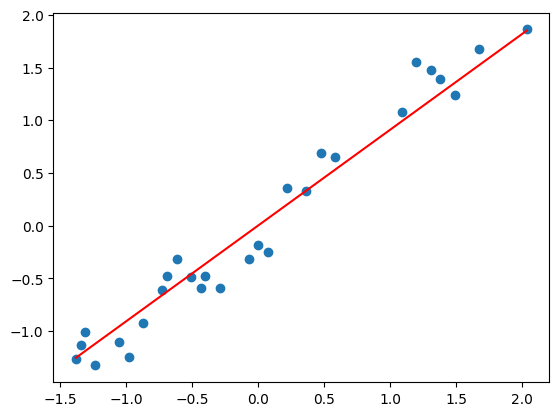

In [32]:
plt.scatter(X_train,y_train)
y_hat = linear_regression(Xr,w0=0,w1=best_theta1_2)
plt.plot(Xr,y_hat,c="r")

In [33]:
losses.shape

torch.Size([100])

In [34]:
def gradient_decent(x,y,eta,w0,w1):
   # gradient
   grad_w0 = 2 * torch.mean(y_hat - y)
   grad_w1 = 2 * torch.mean(x*(y_hat - y))

   #update
   w0 = w0 - eta * grad_w0
   w1 = w1 - eta * grad_w1

   return w0,w1

In [35]:
y_hat = model2(X_train)

loss = mse(y_hat, y_train)
print(loss)

gradient_decent(X_train,y_train,0.5,model2.w0,model2.w1)

tensor(4.6240)


(tensor([-1.3039e-08]), tensor([0.9818]))

In [38]:
def calc_gradient(X,y,y_hat):
    grad_w0 = 2 * torch.mean(y_hat - y)
    grad_w1 = 2 * torch.mean(X*(y_hat - y))
    return grad_w0,grad_w1

In [39]:
def update_gradient(w0,w1,eta,grad_w0,grad_w1):
    w0 = w0 - eta * grad_w0
    w1 = w1 - eta * grad_w1

    return w0,w1

In [40]:
y_hat = model2(X_train)

loss = mse(y_train,y_hat)
print(loss)

grad_w0, grad_w1 = calc_gradient(X_train,y_train,y_hat)
print(grad_w0,grad_w1)

model2.w0, model2.w1 = update_gradient(model2.w0,model2.w1, 0.5, grad_w0, grad_w1)

tensor(4.6240)
tensor(0.0285) tensor(-4.2838)


In [41]:
# TODO : Make a class of gradient

In [55]:
w0 = 10
w1 = 4

eta = 0000.1
N = 100

In [56]:
for iter in range(N):
    # model
    y_hat = linear_regression(X_train,w0,w1)

    # loss 
    loss = mse(y_hat, y_train)

    # gradient
    grad_w0, grad_w1 = calc_gradient(X_train, y_train, y_hat)

    # update
    w0, w1 = update_gradient(w0,w1,eta,grad_w0,grad_w1)
    
    # Print
    print(f"Iter : {iter+1}\t Loss : {loss}\t G_w0 : {w0}\t G_w1 : {w1}")

Iter : 1	 Loss : 109.14592742919922	 G_w0 : 8.0	 G_w1 : 3.3963518142700195
Iter : 2	 Loss : 69.86640930175781	 G_w0 : 6.400000095367432	 G_w1 : 2.913433074951172
Iter : 3	 Loss : 44.727516174316406	 G_w0 : 5.119999885559082	 G_w1 : 2.5270981788635254
Iter : 4	 Loss : 28.63862419128418	 G_w0 : 4.095999717712402	 G_w1 : 2.2180302143096924
Iter : 5	 Loss : 18.341732025146484	 G_w0 : 3.2767996788024902	 G_w1 : 1.970775842666626
Iter : 6	 Loss : 11.75172233581543	 G_w0 : 2.6214396953582764	 G_w1 : 1.7729723453521729
Iter : 7	 Loss : 7.534115791320801	 G_w0 : 2.097151756286621	 G_w1 : 1.6147295236587524
Iter : 8	 Loss : 4.834847927093506	 G_w0 : 1.677721381187439	 G_w1 : 1.4881353378295898
Iter : 9	 Loss : 3.107316732406616	 G_w0 : 1.342177152633667	 G_w1 : 1.3868600130081177
Iter : 10	 Loss : 2.001697063446045	 G_w0 : 1.0737416744232178	 G_w1 : 1.3058396577835083
Iter : 11	 Loss : 1.294100046157837	 G_w0 : 0.8589933514595032	 G_w1 : 1.2410234212875366
Iter : 12	 Loss : 0.8412382006645203	 G

In [59]:
torch.save(w0,f="w0")
torch.save(w1,f="w1")

In [61]:
y_test_hat = linear_regression(X_test, w0, w1)
loss = mse(y_test,y_test_hat)
loss

tensor(0.0554)